In [15]:
pip install kaleido

  Using cached orjson-3.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (41 kB)
Using cached orjson-3.12.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (131 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [kaleido]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import requests, pandas as pd
from bs4 import BeautifulSoup

url = "https://quotes.toscrape.com"
response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")
data = [{"Quote": q.select_one(".text").text, "Author": q.select_one(".author").text} 
        for q in soup.select(".quote")]

df = pd.DataFrame(data)
df.to_csv("quotes.csv", index=False)
df.to_json("quotes.json", orient="records")
df

,Quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe
5,“Try not to become a man of success. Rather be...,Albert Einstein
6,“It is better to be hated for what you are tha...,André Gide
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt
9,"“A day without sunshine is like, you know, nig...",Steve Martin


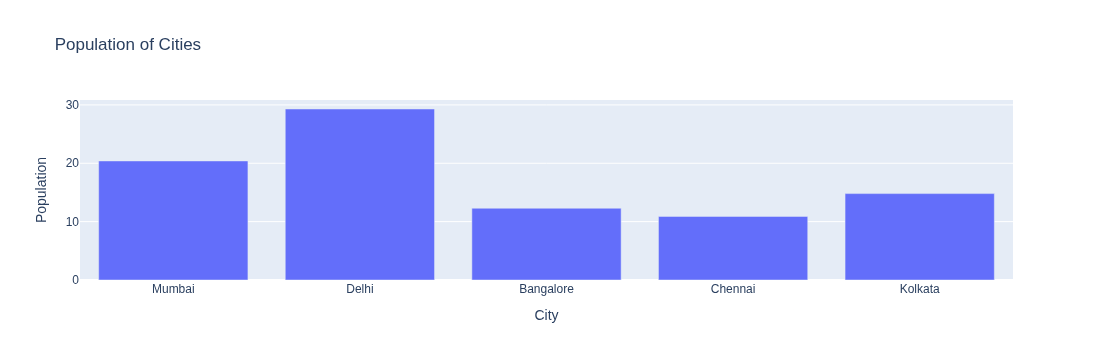

In [2]:
import plotly.express as px

# Small dataset of your own
data = {'City': ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Kolkata'], 
        'Population': [20.4, 29.3, 12.3, 10.9, 14.8]}

# Create and display the interactive bar chart
fig = px.bar(data, x='City', y='Population', title='Population of Cities')
fig.show()

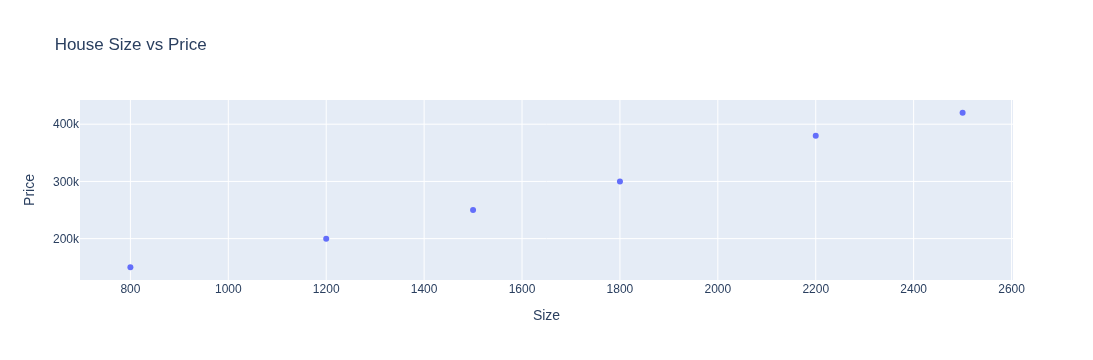

In [4]:
import plotly.express as px

# Small dataset: House Size (sq ft) vs Price ($)
data = {'Size': [800, 1200, 1500, 1800, 2200, 2500], 
        'Price': [150000, 200000, 250000, 300000, 380000, 420000]}

fig = px.scatter(data, x='Size', y='Price', title='House Size vs Price')
fig.show()

In [6]:
from bokeh.plotting import figure, show, output_notebook
output_notebook()

# Data
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
temps = [22, 24, 21, 25, 27, 26, 23]

# FIX: add x_range=days so Bokeh knows the x-axis is categorical
p = figure(title="Daily Temperatures", x_axis_label='Day', y_axis_label='Temp (°C)', x_range=days)

# Draw markers and the line
p.circle(days, temps, size=8, color="red")
p.line(days, temps, line_width=2)

show(p)

Loading BokehJS ...

In [7]:
from bokeh.plotting import figure, show, output_notebook
output_notebook()

# Data: Products and their sales figures
products = ['Laptop', 'Phone', 'Tablet', 'Watch', 'TV']
sales = [150, 300, 120, 80, 200]

# Create figure with categorical x-axis
p = figure(x_range=products, title="Product Sales", x_axis_label='Product', y_axis_label='Sales')

# Draw the bars (vbar = vertical bars)
p.vbar(x=products, top=sales, width=0.5)

show(p)

Loading BokehJS ...

In [9]:
from bokeh.plotting import figure, show, output_notebook
from sklearn.datasets import load_iris
output_notebook()

# Load Iris dataset
iris = load_iris()
x = iris.data[:, 2]  # Petal Length (column index 2)
y = iris.data[:, 3]  # Petal Width (column index 3)

# Create and display the scatter plot
p = figure(title="Iris: Petal Length vs Petal Width", x_axis_label='Petal Length', y_axis_label='Petal Width')
p.scatter(x, y, size=8, color="blue", alpha=0.6)  # alpha makes overlapping dots visible

show(p)

Loading BokehJS ...

In [13]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.io as pio

# 1. Load Iris and cluster into 3 groups
iris = load_iris()
labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(iris.data)

# 2. 3D Scatter: using 3 of the 4 features for x, y, z
fig = px.scatter_3d(
    x=iris.data[:, 0], 
    y=iris.data[:, 1], 
    z=iris.data[:, 2],
    color=labels.astype(str),
    labels={'x': 'Sepal Length', 'y': 'Sepal Width', 'z': 'Petal Length'},
    title="K-Means Clusters on Iris (3D)"
)

# 3. Use an iframe-based renderer that supports WebGL
fig.show(renderer='iframe')

In [17]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.io as pio

# Reset the renderer (removes the earlier 'svg' setting)
pio.renderers.default = "notebook"

# Load Iris and apply PCA to get 2 components
iris = load_iris()
pcs = PCA(n_components=2).fit_transform(iris.data)

# Create interactive 2D scatter plot
fig = px.scatter(
    x=pcs[:, 0], 
    y=pcs[:, 1],
    color=iris.target_names[iris.target],
    labels={'x': 'Principal Component 1', 'y': 'Principal Component 2', 'color': 'Species'},
    title="PCA on Iris Dataset"
)

fig.show(renderer='iframe')   # or 'notebook' / 'browser'